<a href="https://colab.research.google.com/github/nouramar228-cyber/Prediction-of-product-sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title: (Prediction of Product Sales).


Author: **Nour Ammar**





## "Load and Inspect Data"


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


## "Clean Data"


In [4]:
#how many rows
len(df)

8523

In [5]:
#how many columns
len(df.columns)

12

In [6]:
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


In [7]:
duplicated_rows=df.duplicated()
df.duplicated().sum()


np.int64(0)

In [8]:
df.nunique()

,0
Item_Identifier,1559
Item_Weight,415
Item_Fat_Content,5
Item_Visibility,7880
Item_Type,16
Item_MRP,5938
Outlet_Identifier,10
Outlet_Establishment_Year,9
Outlet_Size,3
Outlet_Location_Type,3


In [9]:
df.nunique()/len(df)*100

,0
Item_Identifier,18.291681
Item_Weight,4.869178
Item_Fat_Content,0.058665
Item_Visibility,92.455708
Item_Type,0.187727
Item_MRP,69.670304
Outlet_Identifier,0.117330
Outlet_Establishment_Year,0.105597
Outlet_Size,0.035199
Outlet_Location_Type,0.035199


In [10]:
df.isna()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,False,False,False,False,False,False,False,False,False,False,False,False
8519,False,False,False,False,False,False,False,False,True,False,False,False
8520,False,False,False,False,False,False,False,False,False,False,False,False
8521,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


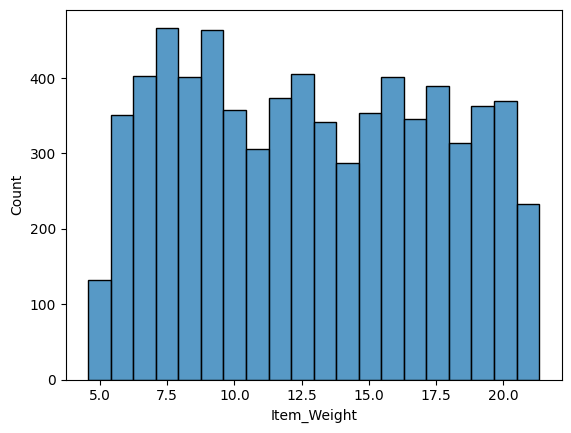

In [12]:
fig,ax = plt.subplots()
ax = sns.histplot(data=df, x="Item_Weight")


*   This histogram shows that the distribution is normal.

*  Strategy #1: To deal with the missing values, we could simply drop the missing values.
*   Strategy #2: To deal with the missing values, we could fill them in with the most frequent for this feature.

*   Strategy #3: To deal with the missing values, we could fill them in with the median/mean value for this feature.
*   To maintain as much data as possible, we will not drop the data. So we will choose either Strategy #2 or Strategy #3. To make this choice we will do a bit more investigating.




In [13]:
print(df['Item_Weight'].mean())
print(df['Item_Weight'].median())

12.857645184135976
12.6


After further investigation, looks like the mean and median have the same value so I will choose to fill in the values with the mean

In [14]:
#handling missing values
df["Item_Weight"]= df['Item_Weight'].fillna(df['Item_Weight'].mean())
df["Item_Weight"].isna().sum()

np.int64(0)

In [15]:
df['Outlet_Size'] = df['Outlet_Size'].fillna("MISSING")
df['Outlet_Size'].isna().sum()

np.int64(0)

In [16]:
#confirm that no missing no values
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [17]:
String_cols = df.select_dtypes("object").columns
for col in String_cols:
  print(f"value counts for {col}")
  print(df[col].value_counts())
  print('\n')

value counts for Item_Identifier
Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64


value counts for Item_Fat_Content
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


value counts for Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


value counts for Outlet_Identifier
Outlet_Identifier
OUT027    935
OUT013

In [18]:
# Standarize the values the Item Fat
df['Item_Fat_Content']= df['Item_Fat_Content'].replace({
  'LF':'Low Fat',
  'low fat': 'Low Fat',
  'reg': 'Regular'
})
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [19]:
df.describe().loc[['min','max','mean']]

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
min,4.555000,0.000000,31.290000,1985.000000,33.290000
max,21.350000,0.328391,266.888400,2009.000000,13086.964800
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914


## "Exploratory Data Analysis"



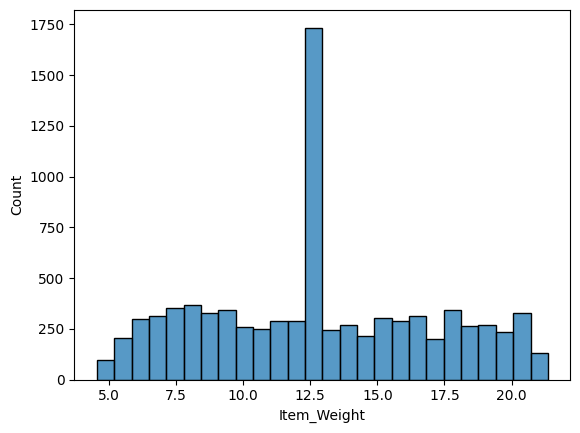

In [20]:
fig,ax = plt.subplots()
ax = sns.histplot(data=df, x="Item_Weight")

This histogram shows that the majority of the weight are around 12,5.

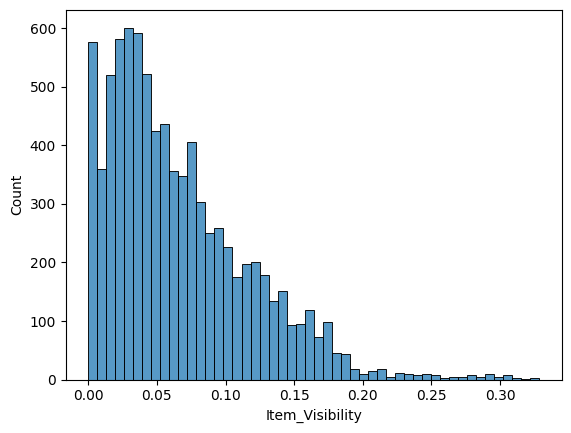

In [21]:
fig,ax = plt.subplots()
ax = sns.histplot(data=df, x="Item_Visibility")

The distribution is Right-skewed.

Most of values have small visibility.


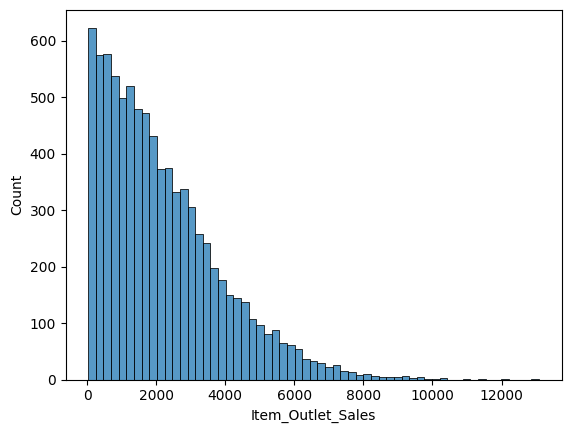

In [22]:
ax = sns.histplot(data=df, x="Item_Outlet_Sales")

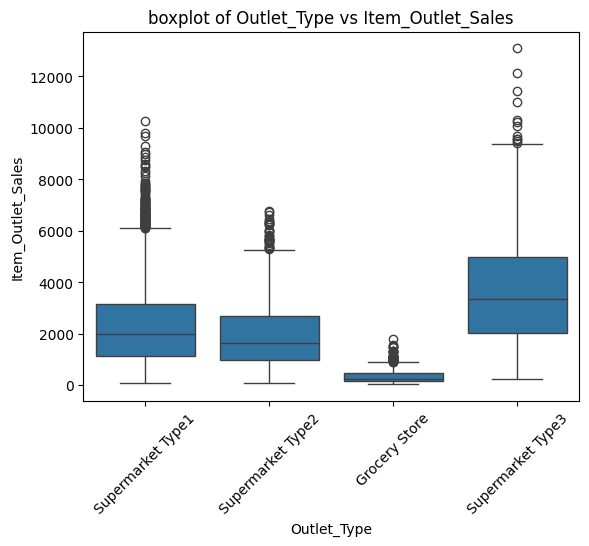

In [23]:
sns.boxplot(data=df, x='Outlet_Type', y='Item_Outlet_Sales')
plt.xticks(rotation=45)
plt.title('boxplot of Outlet_Type vs Item_Outlet_Sales')
plt.show()

Outlet_Type is a strong predictor of sales, as larger supermarkets consistently achieve higher sales compared to smaller grocery stores.

Supermark Type3 have a Top median(Top Sales)

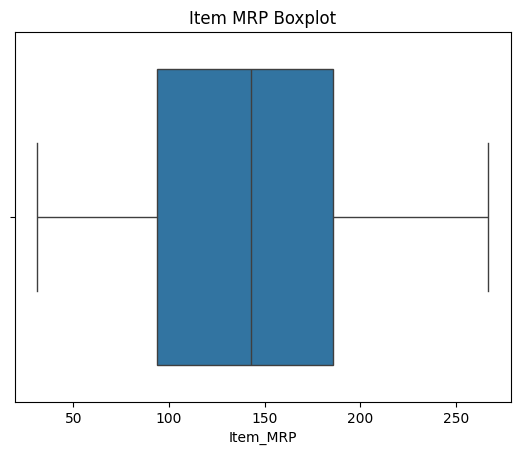

In [24]:
sns.boxplot(x=df['Item_MRP'])
plt.title('Item MRP Boxplot')
plt.savefig('boxplot_mrp.png')
plt.show()

The Item_MRP boxplot reveals that most products have moderate prices, but there are several high-priced outliers. These premium-priced items may contribute differently to sales and should be considered important during modeling.

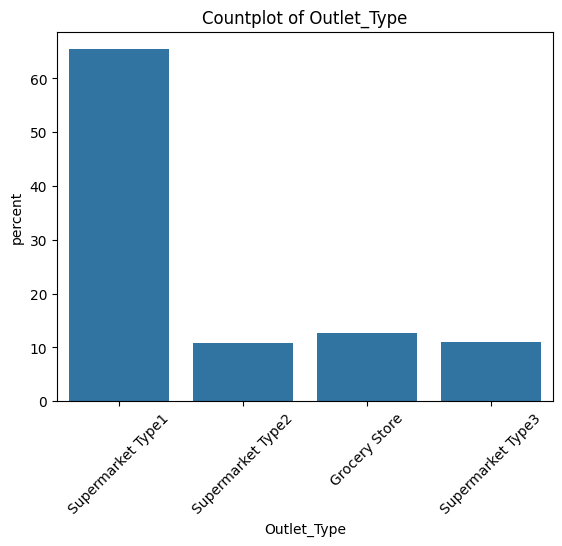

In [25]:
sns.countplot(data=df, x='Outlet_Type', stat='percent')
plt.xticks(rotation=45)
plt.title(f'Countplot of Outlet_Type')
plt.show()

The Supermarket Type1 appears at a higher percentage almost 65%

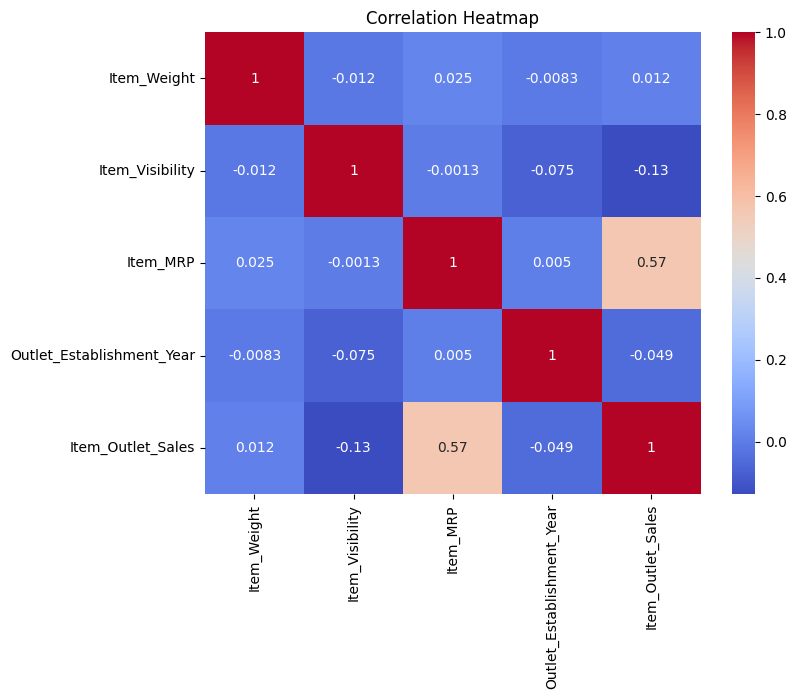

In [26]:

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

There is a strong positive correlation between Item_MRP and Item_Outlet_Sales.

There is a nigative correlation between Item_visibility and Item_Outlet_Sales that means when Item_visibility higher value the Item_Outlet_Sales lower value.

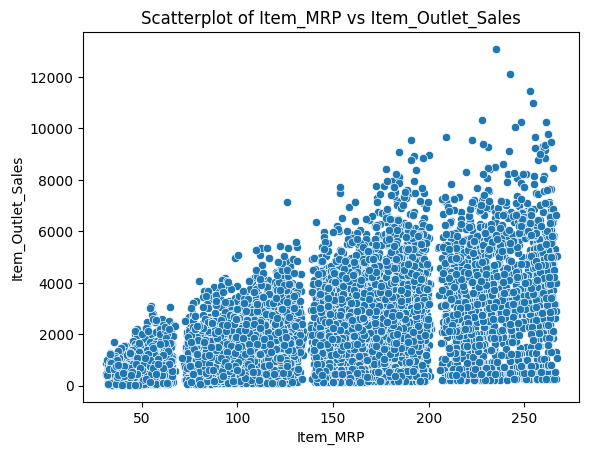

In [27]:
sns.scatterplot(data=df, x='Item_MRP', y='Item_Outlet_Sales')
plt.title('Scatterplot of Item_MRP vs Item_Outlet_Sales')
plt.show()

There is  apositive relationship between product price and sales.

Higher-priced products generate higher profits per sale.

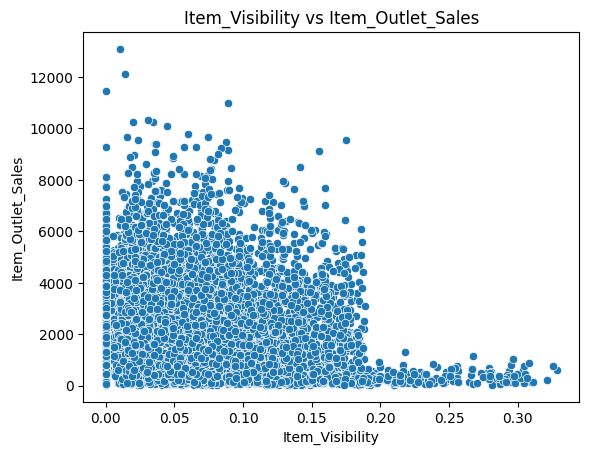

In [28]:
sns.scatterplot(data=df, x='Item_Visibility', y='Item_Outlet_Sales')
plt.title('Item_Visibility vs Item_Outlet_Sales')
plt.show()

The relationship between Item_Visibility and Item_Outlet_Sales weak.

Increased product visibility does not necessarily mean increased sales.

The product appears but undesirable.

The product visibility alone is not a strong predictor of sales.

## "Feature Inspection"


In [29]:
import numpy as np
# Replace placeholders with NaN
df['Outlet_Size'] = df['Outlet_Size'].replace('MISSING', np.nan)

In [30]:
def inspect_feature(df, col):
    print(f"Feature: {col}")
    print("-"*30)
    # Type
    print("Type:", df[col].dtype)

    # null values
    nulls = df[col].isna().sum()
    percent = (nulls / len(df)) * 100
    print(f"Nulls: {nulls} ({percent:.2f}%)")

    # unique values
    print("Unique values:", df[col].nunique())

    # constant
    print("Constant:", df[col].nunique() == 1)

In [31]:
temp_df = df.copy()


In [32]:
target = "Item_Outlet_Sales"

## Feature: Outlet_Size

### Definition
The size of the store in terms of ground area covered.

In [33]:
col='Outlet_Size'
placeholder='NAN'
temp_df[col] = temp_df[col].fillna(placeholder)


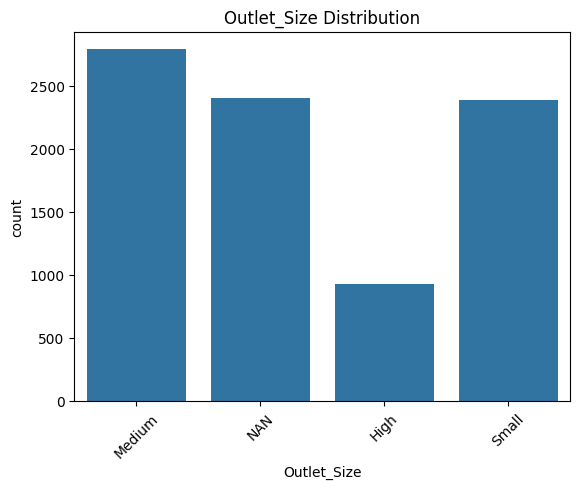

In [34]:
sns.countplot(data=temp_df, x=col);
plt.title(f'{col} Distribution')
plt.xticks(rotation=45)
plt.show()


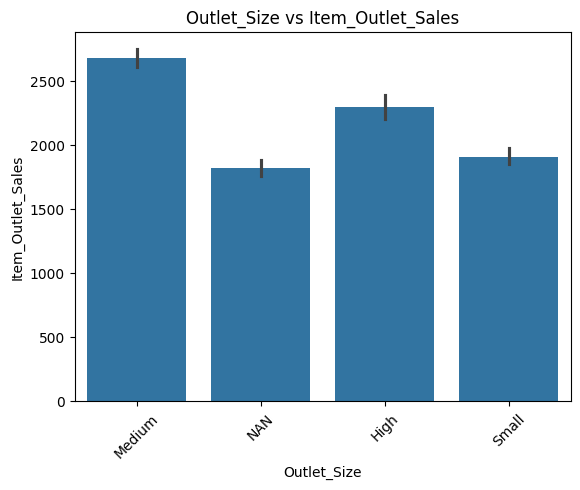

In [35]:
# vs target
sns.barplot(data=temp_df,x=col,y=target)
plt.title(f'{col} vs {target}')
plt.xticks(rotation=45)
plt.show()


In [36]:
# inspection
inspect_feature(df, "Outlet_Size")

Feature: Outlet_Size
------------------------------
Type: object
Nulls: 2410 (28.28%)
Unique values: 3
Constant: False


#### **Feature Type:** Categorical (Ordinal)
#### **Null Values:** Missing values exist and were handled using imputation.
#### **Handling Strategy:** Imputed using "Unknown" or most frequent value since dropping would remove important data.
#### **Constant or Quasi-Constant:** No, multiple categories exist.
#### **Cardinality**:Low (few categories).
#### **Known Before Prediction?** Yes.
#### **Expected Predictor?** Yes,larger stores are expected to generate higher sales.
### **Actual Predictor?** Yes, visualization shows clear differences in sales across outlet sizes.

## Feature: Item_MRP

### Definition
Maximum Retail Price of the product.

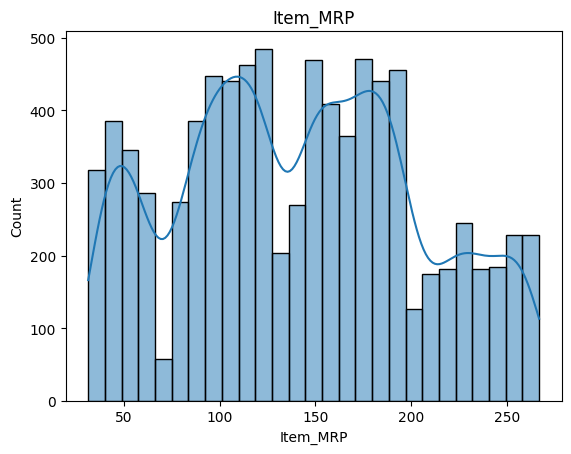

In [37]:
col = "Item_MRP"

sns.histplot(df[col], kde=True)
plt.title(col)
plt.show()



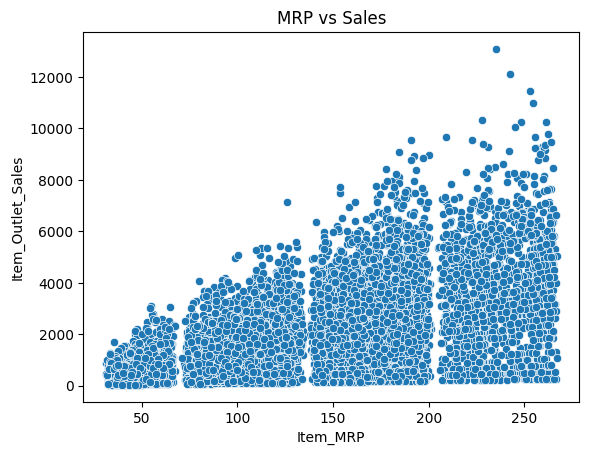

Feature: Item_MRP
------------------------------
Type: float64
Nulls: 0 (0.00%)
Unique values: 5938
Constant: False


In [38]:
sns.scatterplot(data=df, x=col, y="Item_Outlet_Sales")
plt.title("MRP vs Sales")
plt.show()

inspect_feature(df, col)

#### **Feature Type:** Numeric

#### **Null Values:** No missing values.


#### **Constant or Quasi-Constant:** No.

#### **Cardinality:** High (continuous variable).


#### **Known Before Prediction?** Yes.


#### **Expected Predictor?** Yes, price is strongly related to sales.

#### **Actual Predictor?** Yes, clear positive relationship observed.


## Feature: Outlet_Type

### Definition
Type of outlet (grocery store or supermarket).

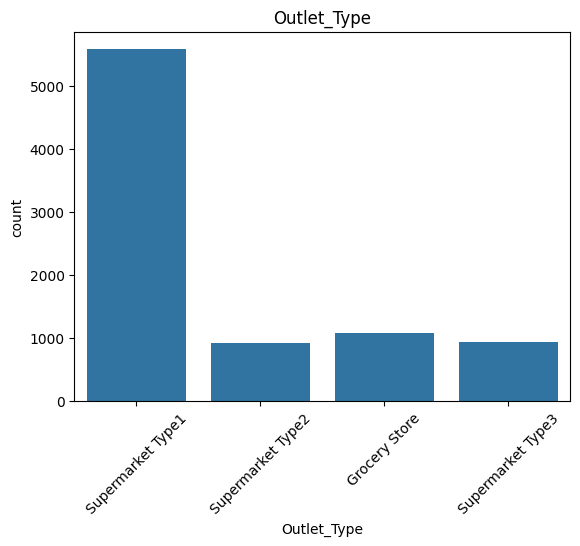

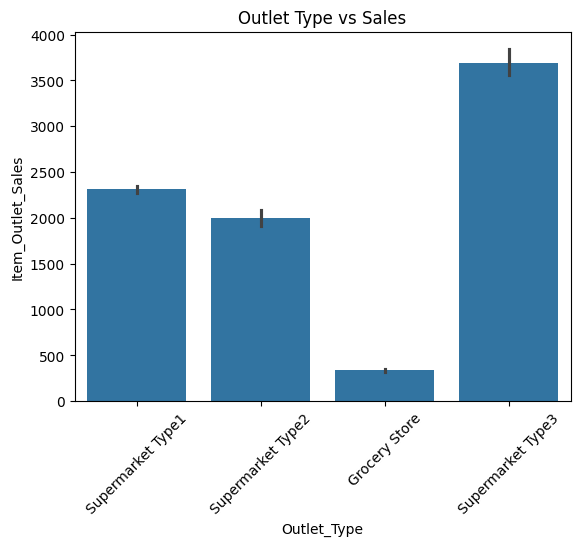

Feature: Outlet_Type
------------------------------
Type: object
Nulls: 0 (0.00%)
Unique values: 4
Constant: False


In [39]:
col = "Outlet_Type"

sns.countplot(data=df, x=col)
plt.xticks(rotation=45)
plt.title(col)
plt.show()

sns.barplot(data=df, x=col, y="Item_Outlet_Sales")
plt.xticks(rotation=45)
plt.title("Outlet Type vs Sales")
plt.show()

inspect_feature(df, col)

#### **Feature Type:** Categorical (Nominal)

#### **Null Values:** No missing values.



#### **Cardinality:** Low


#### **Known Before Prediction?** Yes.


#### **Expected Predictor?** Yes

#### **Actual Predictor?** Yes, Supermarket Type3 shows highest sales.

Type1 is the most common outlet type.
- Supermarket Type3 has the highest average sales.
- Outlet type strongly affects product sales.

## Feature: Item_Visibility

### Definition
The percentage of total display area of all products in
a store allocated to the particular product

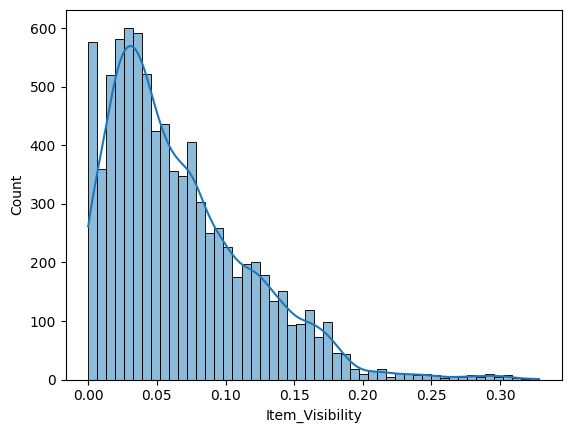

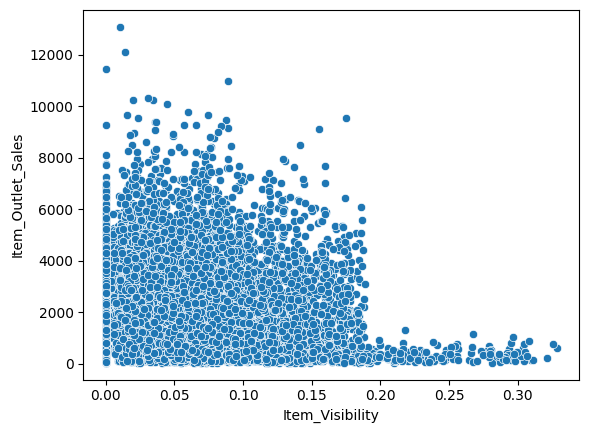

Feature: Item_Visibility
------------------------------
Type: float64
Nulls: 0 (0.00%)
Unique values: 7880
Constant: False


In [40]:
col = "Item_Visibility"

sns.histplot(df[col], kde=True)
plt.show()

sns.scatterplot(data=df, x=col, y="Item_Outlet_Sales")
plt.show()

inspect_feature(df, col)

#### **Feature Type:** Numeric
#### **Null Values:** No missing values.


#### **Expected Predictor?** Yes

#### **Actual Predictor?** Weak relationship observed.

Insight:
- Most products have low visibility values.
- A few products have very high visibility.
- Visibility may slightly influence sales.

## Feature: Item_Type
### Definition
Category of the product.

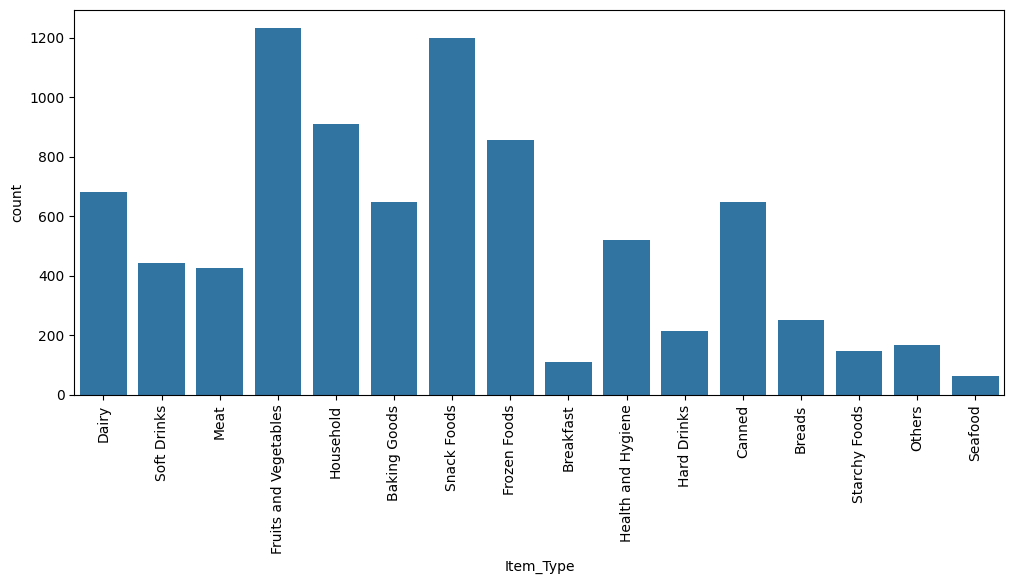

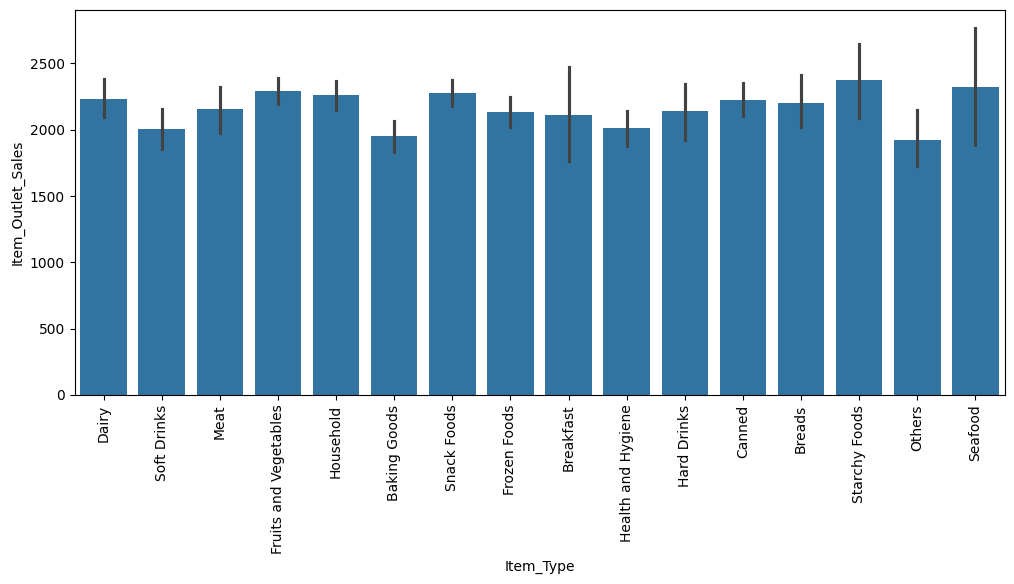

Feature: Item_Type
------------------------------
Type: object
Nulls: 0 (0.00%)
Unique values: 16
Constant: False


In [41]:
col = "Item_Type"

plt.figure(figsize=(12,5))
sns.countplot(data=df, x=col)
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(12,5))
sns.barplot(data=df, x=col, y="Item_Outlet_Sales")
plt.xticks(rotation=90)
plt.show()

inspect_feature(df, col)

#### **Feature Type** Categorical (Nominal)

#### **Cardinality** High (~16 categories)

#### **Expected Predictor?** Yes

#### **Actual Predictor?** Some categories perform better than others.

## Feature: Outlet_Location_Type

### Definition
The type of area in which the store is located

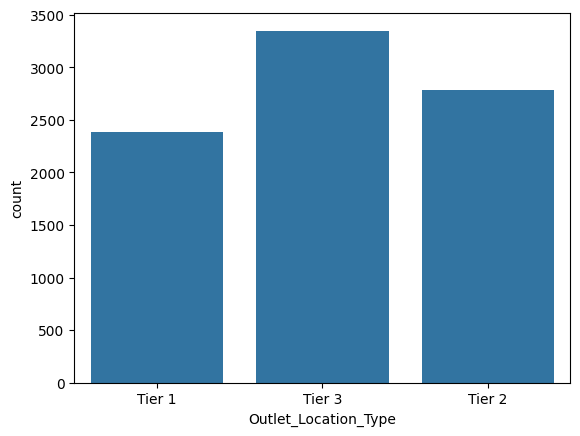

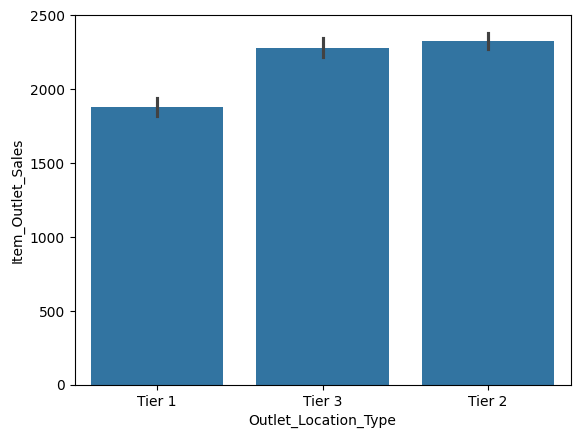

Feature: Outlet_Location_Type
------------------------------
Type: object
Nulls: 0 (0.00%)
Unique values: 3
Constant: False


In [42]:
col = "Outlet_Location_Type"

sns.countplot(data=df, x=col)
plt.show()

sns.barplot(data=df, x=col, y="Item_Outlet_Sales")
plt.show()

inspect_feature(df, col)

#### **Feature Type:** Categorical

#### **Expected Predictor?** Yes

#### **Actual Predictor?** Yes, Tier 3 performs better.

## Feature: Item_Weight

### Definition
Weight of product


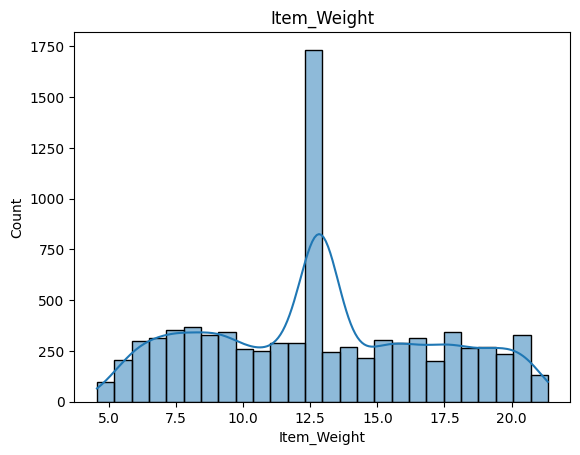

In [43]:
col = "Item_Weight"

sns.histplot(df[col], kde=True)
plt.title(col)
plt.show()


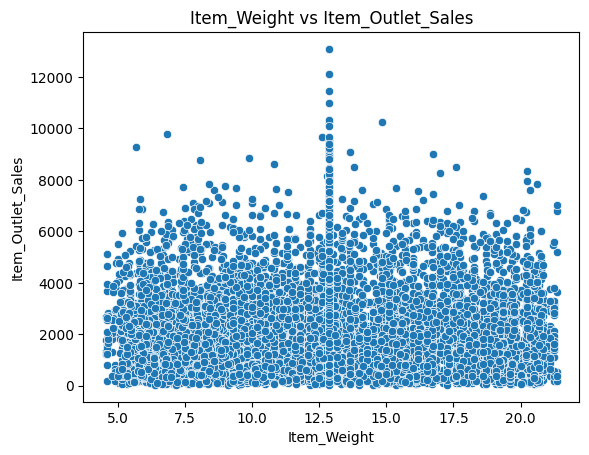

Feature: Item_Weight
------------------------------
Type: float64
Nulls: 0 (0.00%)
Unique values: 416
Constant: False


In [44]:
sns.scatterplot(data=df,x=col,y=target)
plt.title(f'{col} vs {target}')
plt.show()
inspect_feature(df, col)

Insight:
- Product weights are normally distributed.
- There is no strong visible relationship between weight and sales.

# Prepare Data for Machine Learning

### Imports

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [46]:
df = pd.read_csv("/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv")


In [47]:
# Fix inconsistent categorical data.
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF':'Low Fat',
    'low fat':'Low Fat',
    'reg':'Regular'
})

# Remove duplicates

df = df.drop_duplicates()

In [48]:
# Define Features and Target
X = df.drop(columns=['Item_Outlet_Sales', 'Item_Identifier'])
y = df['Item_Outlet_Sales']

In [49]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42
)

In [50]:
# Define Numerical and Categorical Columns
num_cols = X_train.select_dtypes(include='number').columns
nominal_cols = [
    'Item_Fat_Content',
    'Item_Type',
    'Outlet_Identifier',
    'Outlet_Location_Type',
    'Outlet_Type'
]

ordinal_cols = ['Outlet_Size']

In [51]:
outlet_size_order = [['Small', 'Medium', 'High']]

In [52]:
# Pipelines
# Numeric
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
# Nominal
nominal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
# ordinal
ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=outlet_size_order))
])

In [53]:
# Column Transformer
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('nominal', nominal_transformer, nominal_cols),
     ('ordinal', ordinal_transformer, ordinal_cols)
])

## "Linear Regression Model"

In [54]:
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Item_Fat_Content',
                                                   'Item_Type',
                                                   'Outlet_Identifier',
                                                   'Outlet_Location_Type',
                                                   'Outlet_Type']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(categories=[['Small',
                                                                                               'Medium',
                                                                                               'High']]))]),
                                                  ['Outlet_Size'])])),
                ('model', LinearRegression())])

In [55]:
# Evaluate Function
def evaluate_model(model, X_train, X_test, y_train, y_test):

    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

    print('Train R2:', train_r2)
    print('Test R2:', test_r2)
    print('Train RMSE:', train_rmse)
    print('Test RMSE:', test_rmse)

In [56]:
evaluate_model(lr_model, X_train, X_test, y_train, y_test)

Train R2: 0.5594752325504482
Test R2: 0.5792663048499824
Train RMSE: 1141.5315993315069
Test RMSE: 1069.365040308871


## Linear Regression Evaluation

The Linear Regression model shows moderate predictive performance.

The training and testing R² scores are relatively close, indicating that the model is not severely overfitting. However, the overall performance suggests that the model may be slightly underfitting because it cannot fully capture nonlinear relationships in the data.

## "Random Forest Model"

In [57]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Item_Fat_Content',
                                                   'Item_Type',
                                                   'Outlet_Identifier',
                                                   'Outlet_Location_Type',
                                                   'Outlet_Type']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(categories=[['Small',
                                                                                               'Medium',
                                                                                               'High']]))]),
                                                  ['Outlet_Size'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [58]:
evaluate_model(rf_model, X_train, X_test, y_train, y_test)

Train R2: 0.93740110337715
Test R2: 0.5688625478231947
Train RMSE: 430.3146301510965
Test RMSE: 1082.505745764869


## Random Forest Evaluation

The Random Forest model achieved much higher training performance than testing performance.

This indicates overfitting because the model learned the training data too well and struggled to generalize to unseen data.

## Model Comparison

The Random Forest model showed signs of overfitting, achieving excellent training performance but slightly lower test performance than Linear Regression. This motivated the use of hyperparameter tuning to improve generalization

## "Hyperparameter Tuning"

In [59]:
params = {
    'model__n_estimators':[100,200],
    'model__max_depth':[5,10,None]
}
gridsearch = GridSearchCV(
    rf_model,
    params,
    cv=5,
    scoring='r2'
)
gridsearch.fit(X_train, y_train)
best_model = gridsearch.best_estimator_

In [60]:
evaluate_model(best_model, X_train, X_test, y_train, y_test)

Train R2: 0.6076297373986579
Test R2: 0.6170501447425981
Train RMSE: 1077.3351139950037
Test RMSE: 1020.2187234141632


## Tuned Random Forest Evaluation

After hyperparameter tuning, the Random Forest model showed improved test performance and reduced overfitting.

The tuned model achieved the best balance between accuracy and generalization.

# Final Model Recommendation

The Tuned Random Forest model is recommended for deployment because it achieved the highest test performance while maintaining good generalization.

This model can explain approximately 60% of the variability in sales predictions based on product and outlet characteristics.

## Stakeholder-Friendly Interpretation

The model can successfully identify important patterns affecting retail sales and provides reasonably accurate sales predictions for future products and stores.

This can help businesses improve pricing strategies, inventory management, and sales forecasting.

## Why RMSE Was Selected

RMSE was selected because it expresses prediction errors in the same units as sales values, making the model performance easier for business stakeholders to understand.

## Overfitting Analysis

The default Random Forest model showed signs of overfitting because training performance was significantly higher than testing performance.

After tuning, the gap between training and testing scores became smaller, indicating improved generalization.

## "Linear Regression Coefficients"

In [61]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
lr_coefficients = lr_model.named_steps['model'].coef_
coef_df = pd.DataFrame({
     'Feature': feature_names,
     'Coefficient': lr_coefficients

})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False).head(10)


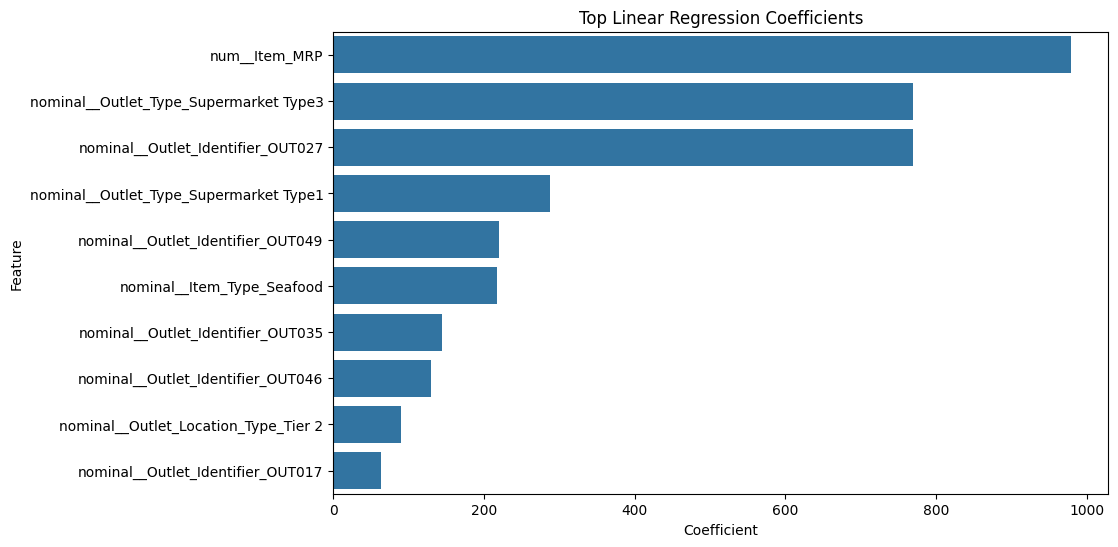

In [62]:
import os

# Create folder
os.makedirs('images', exist_ok=True)

# Plot
plt.figure(figsize=(10,6))

sns.barplot(data=coef_df,
            x='Coefficient',
            y='Feature')

plt.title('Top Linear Regression Coefficients')

# Save figure
plt.savefig('images/linear_regression_coefficients.png',
            bbox_inches='tight')

plt.show()

## Top 3 Most Impactful Features

### Item_MRP
Higher-priced products tend to produce higher sales revenue.

### Outlet_Type_Supermarket_Type3
This outlet type strongly increases product sales.

### 3. Outlet Location
Some outlet locations consistently achieve higher sales compared to others.

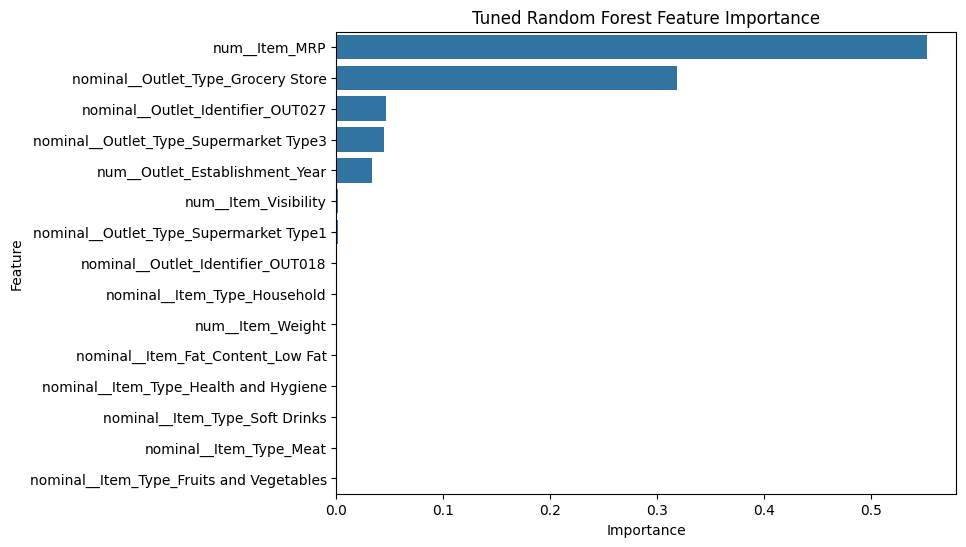

In [71]:
feature_names_rf = best_model.named_steps['preprocessor'].get_feature_names_out()

importances = pd.Series(
    best_model.named_steps['model'].feature_importances_,
    index=feature_names_rf
).sort_values(ascending=False)

# أعلى 15 Feature
top_importances = importances.head(15)

plt.figure(figsize=(8,6))

sns.barplot(
    x=top_importances.values,
    y=top_importances.index
)

plt.title('Tuned Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()